# Florida Housing Cost Burden Analysis

**Dayle Cortes** | UF Alum | Manatee County, FL

---

## What is cost burden?

If a household spends **more than 30% of its income** on housing, experts call it **cost-burdened**.

**Simple example:** Earn $3,000/month. Pay more than $900/month for housing? You are cost-burdened. That leaves less for groceries, gas, medical bills, and emergencies.

- **Moderately burdened:** 31-50% of income goes to housing  
- **Severely burdened:** More than 50% goes to housing  

This notebook maps those households across Florida, with a close look at my home county, **Manatee**, and its neighbors **Sarasota, Pinellas, and Hillsborough**. It then digs deeper: how homeownership has shifted since 1990, whether everyday jobs (teachers, paramedics, cashiers) can cover local rent, and which household types are hit hardest.

**Data:** [UF Shimberg Center for Housing Studies](https://flhousingdata.shimberg.ufl.edu/) (my alma mater's housing research center).

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly maps.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

%matplotlib inline

# My home county (Manatee) plus its neighbors
HOME_AREA = ['Manatee', 'Sarasota', 'Pinellas', 'Hillsborough']


## 1. Load the Excel file (Pandas)

The Shimberg Center download is one `.xlsx` file. **Sheet 1** has cost burden for all households by county and income level.


In [23]:
# Change this path if your file name is different
df = pd.read_excel('../data/affordability-2026-06-09-03-18-46.xlsx', sheet_name='Sheet 1', header=None)
df.head(10)


,0,1,2,3,4
0,"All Households, Cost Burden by Income, 2023 Es...",NaN,NaN,NaN,NaN
1,NaN,NaN,Housing Cost Burden,NaN,NaN
2,Geography,Household Income,30% or less,30.1-50%,More than 50%
3,Alachua County,30% AMI or less,2505,1428,15526
4,Alachua County,30.01-50% AMI,4704,5288,5720
5,Alachua County,50.01-80% AMI,11567,6703,2304
6,Alachua County,80.01-100% AMI,9053,2659,224
7,Alachua County,Greater than 100% AMI,48921,1751,484
8,Baker County,30% AMI or less,164,130,475
9,Baker County,30.01-50% AMI,449,369,210


The first few rows are titles, not data. Row 3 has the real column names, so we skip past the title rows with `.iloc`, give the columns clear names, and drop the empty divider rows.


In [24]:
df = df.iloc[3:]
df.columns = ['county', 'income_band', 'not_burdened', 'mod_burdened', 'severe_burdened']
df = df.dropna(subset=['county', 'income_band'])
df.head()


,county,income_band,not_burdened,mod_burdened,severe_burdened
3,Alachua County,30% AMI or less,2505,1428,15526
4,Alachua County,30.01-50% AMI,4704,5288,5720
5,Alachua County,50.01-80% AMI,11567,6703,2304
6,Alachua County,80.01-100% AMI,9053,2659,224
7,Alachua County,Greater than 100% AMI,48921,1751,484


In [25]:
# Clean county names and make sure numbers are numeric
df['county'] = df['county'].str.replace(' County', '')
df['not_burdened'] = pd.to_numeric(df['not_burdened'])
df['mod_burdened'] = pd.to_numeric(df['mod_burdened'])
df['severe_burdened'] = pd.to_numeric(df['severe_burdened'])

# Missing values check: a few small counties have BLANK cells where the
# estimate was too small for Shimberg to report. Pandas reads a blank as NaN,
# and NaN is contagious: NaN + anything = NaN. If we left them alone, every
# row with one blank would turn into NaN and groupby().sum() would silently
# throw away ALL of that row's households - even the ones we DO know about.
# That inflated some rural counties' burden rates by 15-30 points!
# The safe fix: treat "too small to report" as 0 with fillna(0).
# Audit ALL count columns so it's explicit that not_burdened is never blank
# (only the burdened columns get suppressed), instead of just assuming it.
print('Missing values per column before fillna:')
print(df[['not_burdened', 'mod_burdened', 'severe_burdened']].isna().sum())
df['mod_burdened'] = df['mod_burdened'].fillna(0)
df['severe_burdened'] = df['severe_burdened'].fillna(0)
# Pandas keeps burden columns as float64 after NaN handling; values are still whole household counts.
# Note: We could chain '.astype(int)' right after .fillna(0) to force a downcast back to int64.
# However, leaving them as float64 is syntactically fine because the downstream 
# math and visualizations are unaffected, and the underlying data reflects whole counts.

# "Cost-burdened" = paying more than 30% of income for housing, so:
#   cost_burdened = moderately burdened + severely burdened
#   total_hh      = not burdened + moderately burdened + severely burdened
df['cost_burdened'] = df['mod_burdened'] + df['severe_burdened']
df['total_hh'] = df['not_burdened'] + df['mod_burdened'] + df['severe_burdened']

df.info()


Missing values per column before fillna:
not_burdened        0
mod_burdened        1
severe_burdened    22
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 3 to 337
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   county           335 non-null    object 
 1   income_band      335 non-null    object 
 2   not_burdened     335 non-null    int64  
 3   mod_burdened     335 non-null    float64
 4   severe_burdened  335 non-null    float64
 5   cost_burdened    335 non-null    float64
 6   total_hh         335 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 18.4+ KB


In [26]:
df.describe()


,not_burdened,mod_burdened,severe_burdened,cost_burdened,total_hh
count,335.000000,335.000000,335.000000,335.000000,335.000000
mean,17558.976119,4709.716418,4381.370149,9091.086567,26650.062687
std,42464.409754,9289.409829,11779.444367,17982.131704,50223.705727
min,70.000000,0.000000,0.000000,12.000000,223.000000
25%,999.000000,215.500000,117.000000,439.500000,1749.500000
50%,3173.000000,1289.000000,521.000000,2455.000000,7447.000000
75%,12668.500000,5083.500000,3095.500000,10192.000000,27830.000000
max,320023.000000,81790.000000,128582.000000,152268.000000,360122.000000


## 2. Roll up to county level (groupby)

Roll each county up with `groupby` and `sum`.

**Note:** Miami-Dade and Broward lead on *both* measures - the most cost-burdened households *and* the highest burden rates. (Before the `fillna(0)` fix above, a handful of tiny rural counties wrongly showed rates above 50% because their blank cells made whole rows of households disappear from the math.)


In [27]:
# Sum every income band within each county to get one row per county
county = df.groupby('county')[['cost_burdened', 'severe_burdened', 'total_hh']].sum().reset_index()

# Burden rate formula:
#   burden_rate (%) = (cost-burdened households / total households) * 100
county['burden_rate'] = (county['cost_burdened'] / county['total_hh'] * 100).round(1)
county = county.sort_values('burden_rate', ascending=False)
county.head(10)


,county,cost_burdened,severe_burdened,total_hh,burden_rate
42,Miami-Dade,461815.0,241526.0,990776.0,46.6
5,Broward,328638.0,163089.0,771027.0,42.6
43,Monroe,15366.0,7767.0,37210.0,41.3
48,Osceola,59800.0,28936.0,148270.0,40.3
49,Palm Beach,227763.0,116392.0,609495.0,37.4
47,Orange,202655.0,96656.0,541567.0,37.4
35,Leon,44482.0,22893.0,123958.0,35.9
0,Alachua,42087.0,24258.0,118837.0,35.4
27,Hillsborough,197107.0,94212.0,585955.0,33.6
51,Pinellas,148058.0,69978.0,446933.0,33.1


In [28]:
# Add FIPS codes for maps (small lookup table - standard for GIS work)
fips = pd.read_csv('../data/fl_county_fips.csv')
county = pd.merge(county, fips, on='county')
county.head()


,county,cost_burdened,severe_burdened,total_hh,burden_rate,fips
0,Miami-Dade,461815.0,241526.0,990776.0,46.6,12086
1,Broward,328638.0,163089.0,771027.0,42.6,12011
2,Monroe,15366.0,7767.0,37210.0,41.3,12087
3,Osceola,59800.0,28936.0,148270.0,40.3,12097
4,Palm Beach,227763.0,116392.0,609495.0,37.4,12099


In [29]:
# My hometown counties
home = county[county['county'].isin(HOME_AREA)].sort_values('burden_rate', ascending=False)
home


,county,cost_burdened,severe_burdened,total_hh,burden_rate,fips
8,Hillsborough,197107.0,94212.0,585955.0,33.6,12057
9,Pinellas,148058.0,69978.0,446933.0,33.1,12103
18,Manatee,55725.0,26461.0,184464.0,30.2,12081
27,Sarasota,60588.0,28752.0,211051.0,28.7,12115


## 3. NumPy basics on the burden rates

Two quick stats across all 67 counties:

- **Mean** (average): add up all 67 county rates, divide by 67.
- **Median**: sort the 67 rates from lowest to highest and take the middle one.

If the mean and median are close, no handful of extreme counties is dragging the average around.


In [30]:
# Put the 67 county rates into a NumPy array so we can use NumPy's stats methods
rates = np.array(county['burden_rate'])

# mean   = sum of all rates / number of counties
# median = middle value when the rates are sorted from lowest to highest
print('Mean burden rate:', round(rates.mean(), 1))
print('Median burden rate:', np.median(rates))
print('Highest rate:', rates.max())
print('Lowest rate:', rates.min())


Mean burden rate: 26.8
Median burden rate: 25.9
Highest rate: 46.6
Lowest rate: 10.7


## 4. Matplotlib plots


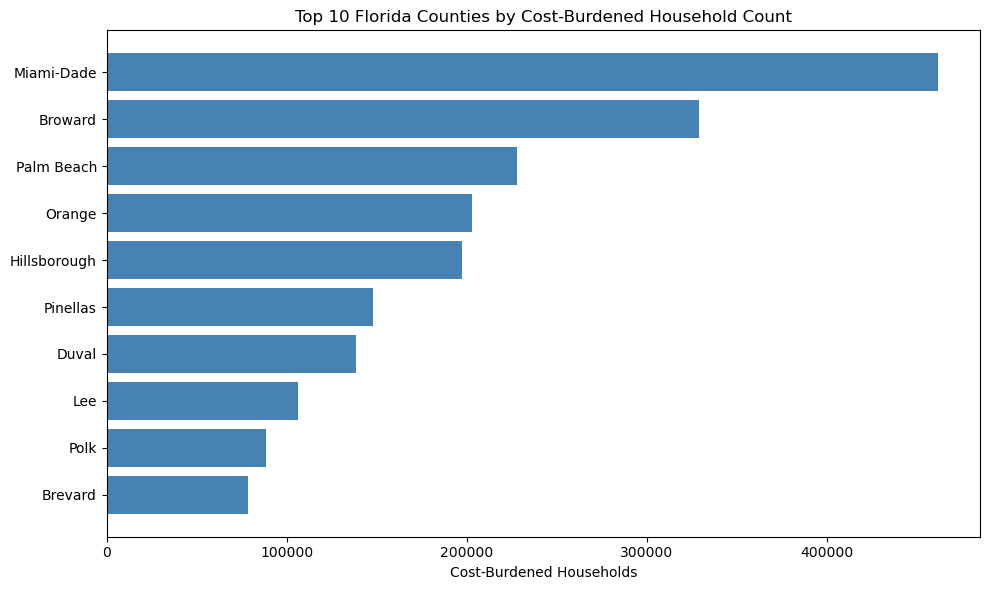

In [31]:
# Top 10 counties by number of cost-burdened households
top10 = county.sort_values('cost_burdened', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10['county'], top10['cost_burdened'], color='steelblue')
plt.xlabel('Cost-Burdened Households')
plt.title('Top 10 Florida Counties by Cost-Burdened Household Count')
plt.gca().invert_yaxis()  # flip the y-axis so the biggest county sits on top
plt.tight_layout()
plt.savefig('../outputs/figures/top10_bar.png')
plt.show()


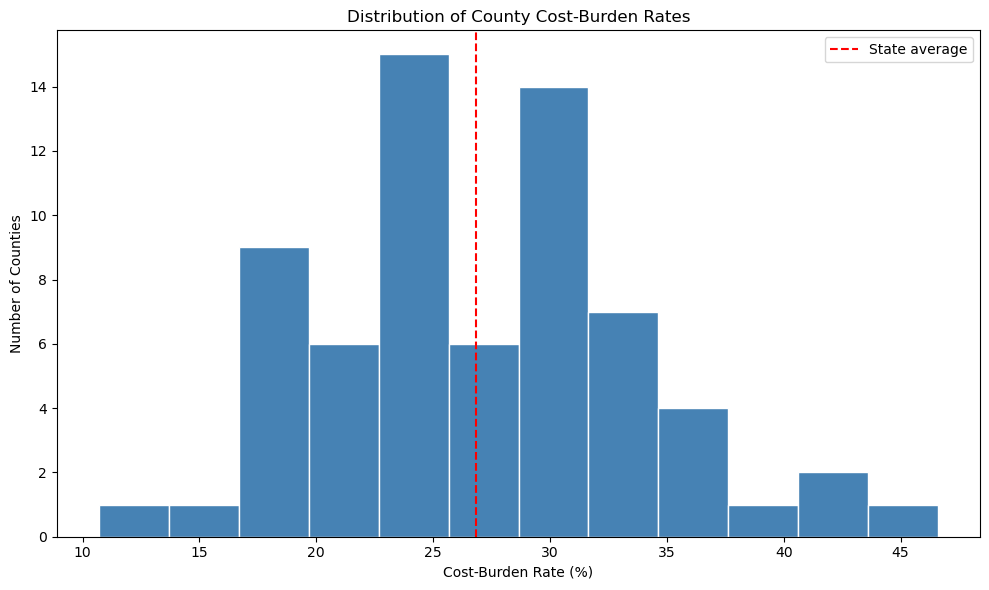

In [32]:
# Histogram of county burden rates
plt.figure(figsize=(10, 6))
plt.hist(county['burden_rate'], bins=12, color='steelblue', edgecolor='white')

# Red dashed line = the mean from Section 3 (sum of all rates / 67 counties)
plt.axvline(rates.mean(), color='red', linestyle='--', label='State average')
plt.xlabel('Cost-Burden Rate (%)')
plt.ylabel('Number of Counties')
plt.title('Distribution of County Cost-Burden Rates')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/burden_histogram.png')
plt.show()


## 5. Seaborn plots

The heatmap below uses **percent** (burden rate) so all four counties compare fairly. The statewide choropleth also uses %. Raw household counts would always make Hillsborough look worst just because it has more people.


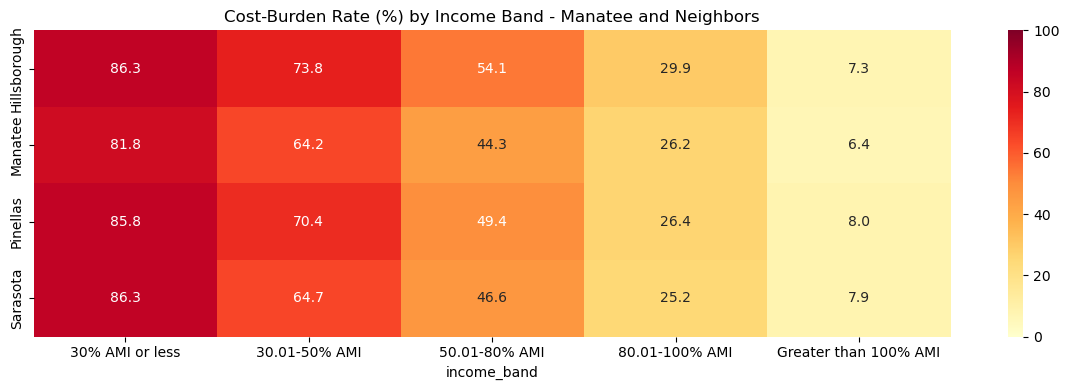

In [33]:
# Heatmap: burden RATE (%) by income band (Manatee and neighbors)
# Percent makes counties comparable. Hillsborough has more people, so raw counts always look hotter.
home_detail = df[df['county'].isin(HOME_AREA)].copy()

# Same burden rate formula as Section 2, but per county AND income band:
#   burden_pct (%) = (cost-burdened households / total households) * 100
home_detail['burden_pct'] = (home_detail['cost_burdened'] / home_detail['total_hh'] * 100).round(1)

# Reshape: one row per county, one column per income band (perfect for a heatmap)
pivot = home_detail.pivot_table(index='county', columns='income_band', values='burden_pct')
pivot = pivot.fillna(0)

# Reorder the columns so income goes from lowest (left) to highest (right)
band_order = ['30% AMI or less', '30.01-50% AMI', '50.01-80% AMI', '80.01-100% AMI', 'Greater than 100% AMI']
pivot = pivot[band_order]

plt.figure(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100)
plt.title('Cost-Burden Rate (%) by Income Band - Manatee and Neighbors')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/home_heatmap.png')
plt.show()


**What does AMI mean in real dollars here?** The cost-burden sheets only give *relative* bands (30% AMI, 50% AMI...), but `Sheet 5` of the same export has actual median household incomes. These ACS medians are a close proxy for HUD's official AMI (which is set per metro area, not per county), so they give a good sense of scale: in Manatee, "30% AMI or less" works out to roughly $24,000/year or less.

Notice in the table below that **renters earn only one-half to two-thirds of what owners earn** (51% in Hillsborough, about 64-65% in the other three) - one reason the renter burden rates in the next chart are so much higher.


In [34]:
# Median household income for the four home counties (Sheet 5 = Median Income by Tenure)
mi = pd.read_excel('../data/affordability-2026-06-09-03-18-46.xlsx', sheet_name='Sheet 5', header=None)
mi = mi.iloc[3:]
mi.columns = ['county', 'acs_source', 'owner_income', 'owner_moe', 'renter_income', 'renter_moe', 'all_income', 'all_moe']
mi['county'] = mi['county'].astype(str).str.replace(' County', '')

# Keep just my four counties and the three income columns
home_mi = mi[mi['county'].isin(HOME_AREA)][['county', 'all_income', 'owner_income', 'renter_income']]
home_mi = home_mi.sort_values('all_income', ascending=False).reset_index(drop=True)

# Median income = line every household up by income; the middle one is the median
print('Median household income, 2024 estimates (proxy for AMI):')
home_mi

Median household income, 2024 estimates (proxy for AMI):


,county,all_income,owner_income,renter_income
0,Hillsborough,85183,112238,57605
1,Sarasota,83003,95105,60628
2,Manatee,81395,95294,61281
3,Pinellas,73832,85139,55310


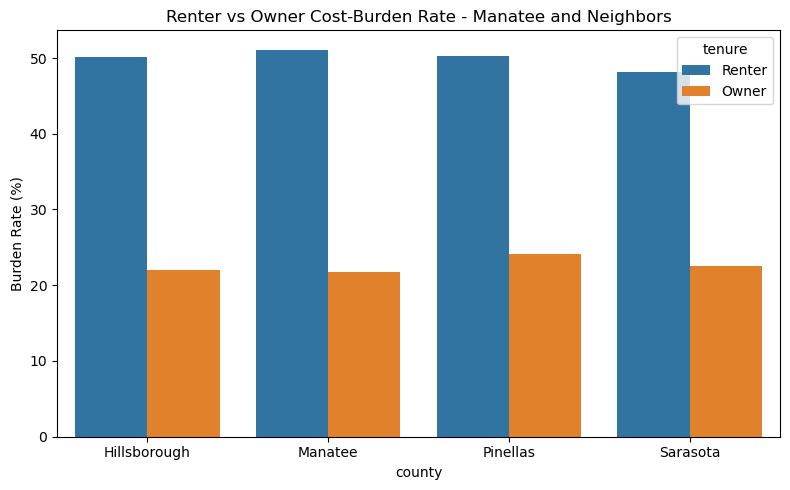

In [35]:
# Bar plot: renter vs owner burden rate in my four counties.
# Sheet 2 = renters, Sheet 3 = owners. Both need the EXACT same cleaning
# as Sheet 1, so instead of copy-pasting those steps twice, we wrap them
# in a function and call it once per sheet (DRY: Don't Repeat Yourself).

def load_cost_burden_sheet(sheet_name):
    """Load one Shimberg sheet and apply the same cleaning steps as Section 1."""
    data = pd.read_excel('../data/affordability-2026-06-09-03-18-46.xlsx', sheet_name=sheet_name, header=None)
    data = data.iloc[3:]  # skip the title rows
    data.columns = ['county', 'income_band', 'not_burdened', 'mod_burdened', 'severe_burdened']
    data = data.dropna(subset=['county'])
    data['county'] = data['county'].str.replace(' County', '')
    for col in ['not_burdened', 'mod_burdened', 'severe_burdened']:
        # fillna(0): blank cell = "too small to report", same fix as Section 1
        data[col] = pd.to_numeric(data[col]).fillna(0)
    # cost_burdened = moderately burdened + severely burdened (paying > 30% of income)
    data['cost_burdened'] = data['mod_burdened'] + data['severe_burdened']
    data['total_hh'] = data['not_burdened'] + data['mod_burdened'] + data['severe_burdened']
    return data

renters = load_cost_burden_sheet('Sheet 2')
owners = load_cost_burden_sheet('Sheet 3')

# Roll each up to county level, then apply the same rate formula as Section 2:
#   burden_rate (%) = (cost-burdened households / total households) * 100
r = renters.groupby('county')[['cost_burdened', 'total_hh']].sum().reset_index()
r['burden_rate'] = (r['cost_burdened'] / r['total_hh'] * 100).round(1)
r['tenure'] = 'Renter'

o = owners.groupby('county')[['cost_burdened', 'total_hh']].sum().reset_index()
o['burden_rate'] = (o['cost_burdened'] / o['total_hh'] * 100).round(1)
o['tenure'] = 'Owner'

# Stack renters and owners into one table so Seaborn can split the bars by tenure
compare = pd.concat([r, o])
compare = compare[compare['county'].isin(HOME_AREA)]

plt.figure(figsize=(8, 5))
sns.barplot(data=compare, x='county', y='burden_rate', hue='tenure')
plt.title('Renter vs Owner Cost-Burden Rate - Manatee and Neighbors')
plt.ylabel('Burden Rate (%)')
plt.tight_layout()
plt.savefig('../outputs/figures/renter_owner_bar.png')
plt.show()


## 6. Plotly choropleth maps

Interactive maps using county FIPS codes and Plotly's US counties GeoJSON. Hover over a county to see its name, burden rate, and household count.


In [36]:
# Florida statewide map.
# Build the hover text as a new column by joining strings together
# (<br> = line break inside a Plotly hover box)
county['text'] = ('<b>' + county['county'] + ' County</b><br>' +
                  'Burden Rate: ' + county['burden_rate'].astype(str) + '%<br>' +
                  'Cost-Burdened Households: ' + county['cost_burdened'].apply(lambda x: f'{int(x):,}'))

data = dict(
    type='choropleth',
    locations=county['fips'].astype(str),
    z=county['burden_rate'],
    text=county['text'],
    hoverinfo='text',
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    colorscale='YlOrRd',
    colorbar=dict(title='Burden Rate (%)', ticksuffix='%'),
    zmin=10,
    zmax=50
)

layout = dict(
    title='Florida Cost-Burden Rate by County (UF Shimberg Center Data)',
    geo=dict(
        scope='usa',
        projection=dict(type='albers usa'),
        center=dict(lat=28, lon=-82),
        lataxis=dict(range=[24, 31]),
        lonaxis=dict(range=[-88, -79]),
        showlakes=True,
        lakecolor='rgb(87,173,240)'
    )
)

fig = go.Figure(data=[data], layout=layout)
fig.show()
fig.write_html('../outputs/figures/florida_map.html')
# Also save a static PNG preview so the README can show the map on GitHub
fig.write_image('../outputs/figures/florida_map_preview.png', width=900, height=600, scale=2)


In [37]:
# Zoom in on my four counties (.copy() so we edit a real new DataFrame, not a view)
sc = county[county['county'].isin(HOME_AREA)].copy()

# Hover text again - household count listed first, since that is what this map colors by
sc['text'] = ('<b>' + sc['county'] + ' County</b><br>' +
              'Cost-Burdened Households: ' + sc['cost_burdened'].apply(lambda x: f'{int(x):,}') + '<br>' +
              'Burden Rate: ' + sc['burden_rate'].astype(str) + '%')

data = dict(
    type='choropleth',
    locations=sc['fips'].astype(str),
    z=sc['cost_burdened'],
    text=sc['text'],
    hoverinfo='text',
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    colorscale='YlOrRd',
    colorbar=dict(title='Cost-Burdened<br>Households', tickformat=','),
)

layout = dict(
    title='Manatee County and Neighbors: Cost-Burdened Households',
    geo=dict(
        scope='usa',
        projection=dict(type='albers usa'),
        center=dict(lat=27.77, lon=-82.53),
        lataxis=dict(range=[26.4, 28.6]),
        lonaxis=dict(range=[-83.3, -81.8]),
        showlakes=True,
        lakecolor='rgb(87,173,240)'
    )
)

fig = go.Figure(data=[data], layout=layout)
fig.show()
fig.write_html('../outputs/figures/home_map.html')
# Static PNG preview for the README, same as the statewide map
fig.write_image('../outputs/figures/home_map_preview.png', width=900, height=600, scale=2)


## 7. Homeownership over time (Sheet 4)

Cost burden is a snapshot of one year. `Sheet 4` of the same export adds a time dimension: the **homeownership rate** (the share of households that own their home) for every county in 1990, 2000, 2010, 2020, and 2024.

Pandas DataFrames have a built-in `.plot()` method (it uses Matplotlib under the hood), and `.T` (transpose) flips the table so the years become the x-axis.

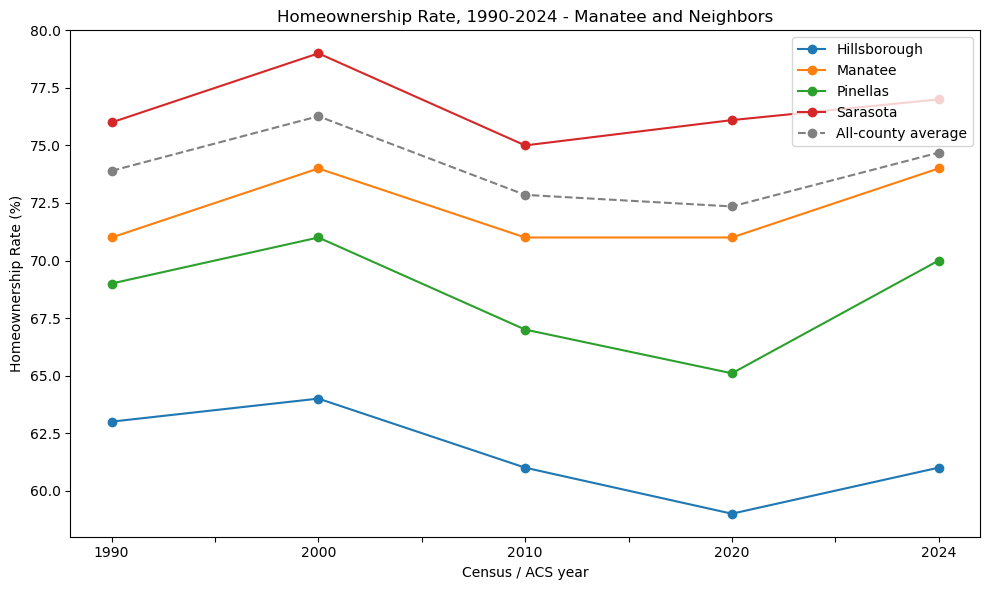

In [38]:
# Sheet 4 = homeownership rate (as a fraction) by county, 1990 through 2024
own = pd.read_excel('../data/affordability-2026-06-09-03-18-46.xlsx', sheet_name='Sheet 4', header=None)
own = own.iloc[3:]  # skip the title rows, same as before
own.columns = ['county', '1990', '2000', '2010', '2020', '2024']
own['county'] = own['county'].str.replace(' County', '')

# Keep my four counties, make county the index, and turn fractions into %
home_own = own[own['county'].isin(HOME_AREA)].set_index('county')
home_own = home_own.astype(float) * 100

# .T flips the table so YEARS become the rows - exactly what a line plot wants
ax = home_own.T.plot(figsize=(10, 6), marker='o')

# Dashed gray line = average of all 67 counties each year, for context
state_own = own.set_index('county').astype(float).mean() * 100
state_own.plot(ax=ax, color='gray', linestyle='--', marker='o', label='All-county average')

plt.title('Homeownership Rate, 1990-2024 - Manatee and Neighbors')
plt.ylabel('Homeownership Rate (%)')
plt.xlabel('Census / ACS year')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/homeownership_trend.png')
plt.show()

## 8. Wages vs rent: who can afford a 2-bedroom? (Sheet 18)

`Sheet 18` compares the **median hourly wage** of real occupations against the **2025 HUD Fair Market Rent (FMR)** - HUD's estimate of a typical 2-bedroom rent - for each metro area. Manatee and Sarasota counties together form the **North Port-Sarasota-Bradenton MSA**.

It is the same 30% rule as the rest of this project, just flipped around: if a typical 2-bedroom costs more than 30% of a worker's income, that worker is cost-burdened. In the chart below, **red bars are jobs where one median wage cannot cover a 2-bedroom** without crossing the 30% line.

2025 HUD Fair Market Rent for a 2-bedroom here: $1,846/month


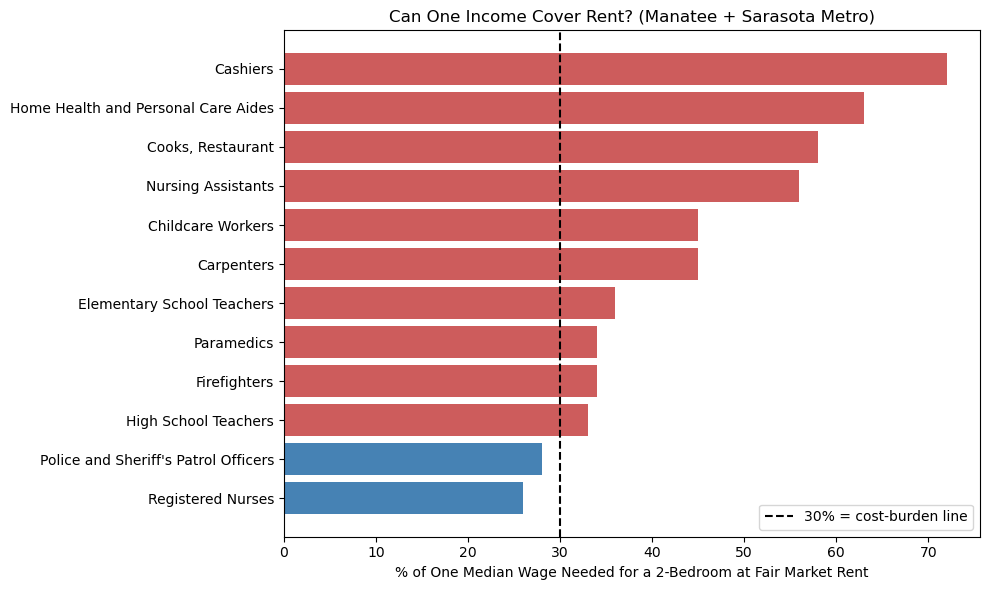

In [39]:
# Sheet 18 = median wage by occupation vs HUD Fair Market Rent, by metro area
wages = pd.read_excel('../data/affordability-2026-06-09-03-18-46.xlsx', sheet_name='Sheet 18', header=None)
wages = wages.iloc[3:]
wages.columns = ['metro', 'occupation', 'hourly_wage', 'max_affordable_rent',
                 'fmr_2br', 'pct_income_for_2br', 'pct_ami']

# Manatee + Sarasota = the North Port-Sarasota-Bradenton metro area
msa = wages[wages['metro'] == 'North Port-Sarasota-Bradenton, FL MSA'].copy()
for col in ['hourly_wage', 'max_affordable_rent', 'fmr_2br', 'pct_income_for_2br']:
    msa[col] = pd.to_numeric(msa[col])

fmr = msa['fmr_2br'].iloc[0]
print(f'2025 HUD Fair Market Rent for a 2-bedroom here: ${fmr:,.0f}/month')

# A mix of everyday local jobs (out of the ~54 occupations in the sheet)
jobs = ['Registered Nurses',
        "Police and Sheriff's Patrol Officers",
        'Secondary School Teachers, Except Special and Career/Technical Education',
        'Firefighters',
        'Paramedics',
        'Elementary School Teachers, Except Special Education',
        'Carpenters',
        'Childcare Workers',
        'Nursing Assistants',
        'Cooks, Restaurant',
        'Home Health and Personal Care Aides',
        'Cashiers']
picked = msa[msa['occupation'].isin(jobs)].copy()

# The sheet stores "% of income needed" as a fraction (0.36 = 36%)
picked['pct_needed'] = picked['pct_income_for_2br'] * 100
picked = picked.sort_values('pct_needed')

# Shorten the two long teacher titles so the chart labels stay readable
picked['occupation'] = picked['occupation'].replace({
    'Secondary School Teachers, Except Special and Career/Technical Education': 'High School Teachers',
    'Elementary School Teachers, Except Special Education': 'Elementary School Teachers'})

plt.figure(figsize=(10, 6))
# Blue = under the 30% line (affordable), red = over it (cost-burdened)
colors = ['steelblue' if p <= 30 else 'indianred' for p in picked['pct_needed']]
plt.barh(picked['occupation'], picked['pct_needed'], color=colors)
plt.axvline(30, color='black', linestyle='--', label='30% = cost-burden line')
plt.xlabel('% of One Median Wage Needed for a 2-Bedroom at Fair Market Rent')
plt.title('Can One Income Cover Rent? (Manatee + Sarasota Metro)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/wage_vs_rent.png')
plt.show()

## 9. Which household types carry the burden? (Sheet 22)

`Sheet 22` splits each county's households four ways - **married couples**, **single-father families** ("male only headed"), **single-mother families** ("female only headed"), and **non-family households** (people living alone or with roommates) - and reports cost burden separately for owners and renters in each group (2020-2024 ACS).

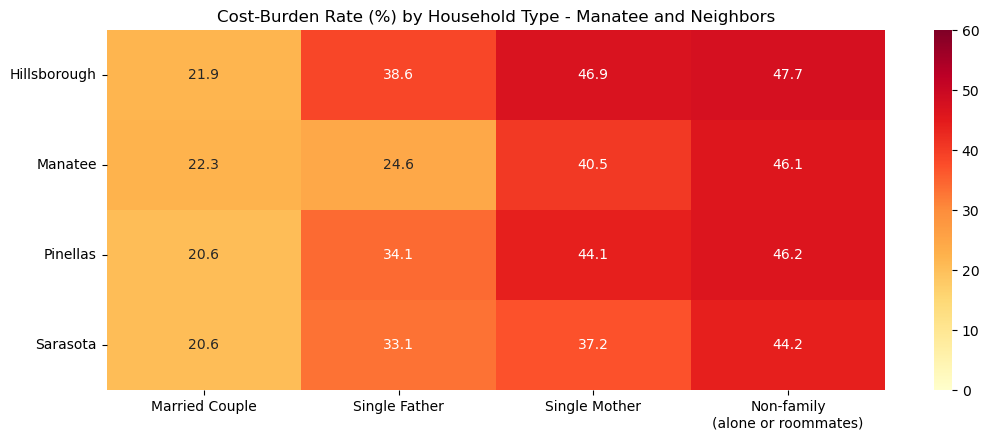

In [40]:
# Sheet 22 = households by tenure, household type, and cost burden
types = pd.read_excel('../data/affordability-2026-06-09-03-18-46.xlsx', sheet_name='Sheet 22', header=None)
types = types.iloc[3:]
types.columns = ['county', 'household_type', 'owner_not_burdened', 'owner_burdened',
                 'renter_not_burdened', 'renter_burdened']
types = types.dropna(subset=['county'])
types['county'] = types['county'].astype(str).str.replace(' County', '')

count_cols = ['owner_not_burdened', 'owner_burdened', 'renter_not_burdened', 'renter_burdened']
for col in count_cols:
    types[col] = pd.to_numeric(types[col]).fillna(0)  # same blank-cell fix as Section 1

home_types = types[types['county'].isin(HOME_AREA)].copy()

# Burden rate for each household type (owners + renters combined),
# using the same formula as everywhere else: burdened / total * 100
home_types['burdened'] = home_types['owner_burdened'] + home_types['renter_burdened']
home_types['total'] = home_types[count_cols].sum(axis=1)
home_types['burden_pct'] = (home_types['burdened'] / home_types['total'] * 100).round(1)

# Pivot: one row per county, one column per household type
type_pivot = home_types.pivot_table(index='county', columns='household_type', values='burden_pct')
type_order = ['Married Couple Household', 'Male Only Headed Family',
              'Female Only Headed Family', 'Non-family household']
type_pivot = type_pivot[type_order]

# Friendlier column labels for the chart
type_pivot.columns = ['Married Couple', 'Single Father', 'Single Mother', 'Non-family\n(alone or roommates)']

plt.figure(figsize=(11, 4.5))
sns.heatmap(type_pivot, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=60)
plt.title('Cost-Burden Rate (%) by Household Type - Manatee and Neighbors')
plt.ylabel('')
plt.xlabel('')
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/household_type_heatmap.png')
plt.show()

In [41]:
# Zoom in on single-mother families who RENT - the hardest-hit group of all
moms = home_types[home_types['household_type'] == 'Female Only Headed Family'].copy()
moms['renter_pct'] = (moms['renter_burdened'] /
                      (moms['renter_not_burdened'] + moms['renter_burdened']) * 100).round(1)
moms[['county', 'burden_pct', 'renter_pct']].sort_values('renter_pct', ascending=False)

,county,burden_pct,renter_pct
209,Pinellas,44.1,62.0
113,Hillsborough,46.9,59.9
161,Manatee,40.5,57.7
233,Sarasota,37.2,54.4


## 10. Key takeaways

A short summary answering the seven questions this project set out to answer. Every number is pulled live from the DataFrames above - nothing is typed in by hand.


In [42]:
# Every number below is pulled from the DataFrames above - nothing is hard-coded
total_burdened = int(county['cost_burdened'].sum())
state_avg = round(rates.mean(), 1)  # mean = sum of all 67 county rates / 67

top_count = county.sort_values('cost_burdened', ascending=False).iloc[0]
by_rate = county.sort_values('burden_rate', ascending=False)
top_rate = by_rate.iloc[0]
second_rate = by_rate.iloc[1]

# Two different "state averages":
#   state_avg  = mean of the 67 county rates (every county counts equally)
#   state_rate = all burdened households / all households (big counties count more)
state_rate = round(county['cost_burdened'].sum() / county['total_hh'].sum() * 100, 1)

r_home = r[r['county'].isin(HOME_AREA)]
o_home = o[o['county'].isin(HOME_AREA)]

low_ami_col = '30% AMI or less'
high_ami_col = 'Greater than 100% AMI'
low_ami_min = pivot[low_ami_col].min()
low_ami_max = pivot[low_ami_col].max()
high_ami_max = pivot[high_ami_col].max()

# Putting "30% AMI or less" into dollars:
#   low_ami_dollars = county median income * 0.30
manatee_mi = int(home_mi.loc[home_mi['county'] == 'Manatee', 'all_income'].iloc[0])
low_ami_dollars = int(manatee_mi * 0.30)

# Look up each home county's burden rate once, so the print lines below stay simple
manatee_rate = home.loc[home['county'] == 'Manatee', 'burden_rate'].iloc[0]
hillsborough_rate = home.loc[home['county'] == 'Hillsborough', 'burden_rate'].iloc[0]
pinellas_rate = home.loc[home['county'] == 'Pinellas', 'burden_rate'].iloc[0]
sarasota_rate = home.loc[home['county'] == 'Sarasota', 'burden_rate'].iloc[0]

print('FLORIDA HOUSING COST BURDEN  -  KEY FINDINGS')
print('=' * 48)
print()
print('1. Which counties have the most cost-burdened households, by count and by rate?')
print(f"   Answer: {top_count['county']}, on both measures.")
print(f"   - Most cost-burdened households: {int(top_count['cost_burdened']):,}")
print(f"   - Highest burden rate of any county: {top_rate['burden_rate']}%")
print(f"     ({top_rate['county']}), with {second_rate['county']} next at {second_rate['burden_rate']}%")
print()
print('2. In Manatee and its neighbors, do renters or owners have a higher burden rate?')
print('   Answer: Renters - about twice as burdened as owners.')
print(f"   - Renters: {r_home['burden_rate'].min():.1f}-{r_home['burden_rate'].max():.1f}% in all four counties")
print(f"   - Owners: {o_home['burden_rate'].min():.1f}-{o_home['burden_rate'].max():.1f}%")
print()
print('3. Which income groups have the highest burden rates in the home area?')
print('   Answer: The lowest earners - burden drops steadily as income rises.')
print(f"   - Households at {low_ami_col}: {low_ami_min:.1f}-{low_ami_max:.1f}% cost-burdened")
print(f"   - Households above 100% AMI: up to {high_ami_max:.1f}%")
print(f"   - In dollars: Manatee median income is about ${manatee_mi:,}, so")
print(f"     \"30% AMI or less\" means roughly ${low_ami_dollars:,}/year or less")
print()
print('4. How do Manatee and its neighbors compare to the rest of Florida?')
print('   Answer: All four sit above the typical Florida county, but below')
print('   the big urban extremes like Miami-Dade and Broward.')
print(f"   - Average county burden rate (mean of 67 county rates): {state_avg}%")
print(f"   - Statewide rate (all burdened households / all households): {state_rate}%")
print('     (Higher than the county average because the biggest counties are the most burdened.)')
print(f"   - Sarasota: {sarasota_rate}% and Manatee: {manatee_rate}% (a bit above the county average)")
print(f"   - Pinellas: {pinellas_rate}% and Hillsborough: {hillsborough_rate}% (further above it)")
print()

# --- The three bonus questions (Sections 7-9) ---
manatee_own_1990 = home_own.loc['Manatee', '1990']
manatee_own_2024 = home_own.loc['Manatee', '2024']

n_jobs = len(picked)
n_over_30 = int((picked['pct_needed'] > 30).sum())
worst_job = picked.iloc[-1]    # picked is sorted by pct_needed, so last = worst

married_max = type_pivot['Married Couple'].max()
moms_min = type_pivot['Single Mother'].min()
moms_max = type_pivot['Single Mother'].max()
moms_rent_max = moms['renter_pct'].max()

print('5. Is homeownership in the home area rising or falling?')
print('   Answer: Remarkably steady for 35 years.')
print(f"   - Manatee: {manatee_own_1990:.0f}% in 1990 vs {manatee_own_2024:.0f}% in 2024")
print('   - The squeeze shows up in PRICES (cost burden), not in who owns')
print()
print('6. Can one median wage cover a typical 2-bedroom near home?')
print(f"   Answer: Usually not. {n_over_30} of the {n_jobs} everyday jobs checked")
print(f"   need more than 30% of income for a ${fmr:,.0f}/month 2-bedroom.")
print(f"   - Toughest spot: {worst_job['occupation']} at {worst_job['pct_needed']:.0f}% of income")
print()
print('7. Which household types carry the most burden?')
print(f"   Answer: Single-mother families ({moms_min:.0f}-{moms_max:.0f}% burdened) and non-family")
print(f"   households, vs at most {married_max:.0f}% for married couples.")
print(f"   - Single mothers who rent: up to {moms_rent_max:.0f}% are cost-burdened")
print()
print(f"Statewide total: {total_burdened:,} cost-burdened households across 67 counties.")

FLORIDA HOUSING COST BURDEN  -  KEY FINDINGS

1. Which counties have the most cost-burdened households, by count and by rate?
   Answer: Miami-Dade, on both measures.
   - Most cost-burdened households: 461,815
   - Highest burden rate of any county: 46.6%
     (Miami-Dade), with Broward next at 42.6%

2. In Manatee and its neighbors, do renters or owners have a higher burden rate?
   Answer: Renters - about twice as burdened as owners.
   - Renters: 48.1-51.1% in all four counties
   - Owners: 21.7-24.1%

3. Which income groups have the highest burden rates in the home area?
   Answer: The lowest earners - burden drops steadily as income rises.
   - Households at 30% AMI or less: 81.8-86.3% cost-burdened
   - Households above 100% AMI: up to 8.0%
   - In dollars: Manatee median income is about $81,395, so
     "30% AMI or less" means roughly $24,418/year or less

4. How do Manatee and its neighbors compare to the rest of Florida?
   Answer: All four sit above the typical Florida count

## 11. Limitations (the honest fine print)

No analysis is perfect. Here is what to keep in mind before quoting these numbers:

1. **Suppressed values.** A few small counties have blank cells where an estimate was too small to report. I treat those as 0 (Section 1). The truth is "somewhere between 0 and small," so tiny counties' rates carry extra uncertainty.
2. **Estimates, not counts.** Everything here comes from survey-based estimates (ACS / CHAS), which have margins of error - especially for small counties and small subgroups. `Sheet 5` even ships a margin-of-error column next to every income figure.
3. **AMI proxy.** I use county median income (ACS) to put AMI bands into dollars. HUD's official AMI is set per metro area with its own adjustments, so "roughly \$24,000" is a good approximation, not the official cutoff.
4. **One earner per household?** Section 8 compares a *single* median wage to rent. Many households have two earners - the chart shows what a solo worker faces, not every household.
5. **Different time windows.** Cost burden sheets are 2023 estimates, median income is 2024, household types are 2020-2024 averages, and FMR is 2025. Each sheet is used on its own terms, but they are not one single snapshot.
6. **Descriptive, not causal.** This project shows *where* and *who*; it does not prove *why* burden is high or what policy would fix it.